# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [70]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [31]:
base_path = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
file_name = r"admission_predict.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0


## 데이터 전처리

In [32]:
print(df.info())
print(df.describe())

df.columns = df.columns.str.strip()
df.columns

print(f"결측값 확인\n{df.isna().sum()}")

# admission_df = df.drop(["Unnamed: 0", "Serial No."], axis=1)
admission_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         400 non-null    int64  
 1   Serial No.         400 non-null    int64  
 2   GRE Score          400 non-null    int64  
 3   TOEFL Score        400 non-null    int64  
 4   University Rating  400 non-null    int64  
 5   SOP                400 non-null    float64
 6   LOR                400 non-null    float64
 7   CGPA               400 non-null    float64
 8   Research           400 non-null    int64  
 9   Chance of Admit    400 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 31.4 KB
None
       Unnamed: 0  Serial No.   GRE Score  TOEFL Score  University Rating  \
count  400.000000  400.000000  400.000000   400.000000         400.000000   
mean   199.500000  200.500000  316.807500   107.410000           3.087500   
std    115.614301  115.614301   

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,1
396,325,107,3,3.0,3.5,9.11,1,1
397,330,116,4,5.0,4.5,9.45,1,1
398,312,103,3,3.5,4.0,8.78,0,0


In [34]:
corr_matrix = admission_df.corr(numeric_only=True)
corr_matrix

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.686138
TOEFL Score,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.672465
University Rating,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.638983
SOP,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.612152
LOR,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.557481
CGPA,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.737307
Research,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.519441
Chance of Admit,0.686138,0.672465,0.638983,0.612152,0.557481,0.737307,0.519441,1.000000


In [35]:
X = admission_df.drop("Chance of Admit", axis=1)
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [36]:
y = admission_df["Chance of Admit"]
y

0      1
1      1
2      0
3      1
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Chance of Admit, Length: 400, dtype: int64

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

[1438.4517892185577,
 1349.7469482740144,
 22.14370533096426,
 38.05017677579483,
 38.41172225388187,
 1080.4911794302955,
 2.8599378196407557]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 7) (80, 7) (320,) (80,)


In [49]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 모델 준비

In [58]:
lr = LogisticRegression()
kn = KNeighborsClassifier(n_neighbors=10)
sv = SVC()

## 모델 학습

In [59]:
lr.fit(X_train_s, y_train)
kn.fit(X_train_s, y_train)
sv.fit(X_train_s, y_train)

SVC()

## 모델 평가

In [84]:
train_score = lr.score(X_train_s, y_train)
test_score = lr.score(X_test_s, y_test)

print(f"lr 정답률 : {train_score}")
print(f"lr 테스트 정답률 : {test_score}")

lr 정답률 : 0.8875
lr 테스트 정답률 : 0.8875


In [88]:
y_pred = lr.predict(X_test_s)

In [89]:
print(f"lr의 예측 확률: {lr.predict_proba(X_test_s)[:5]}")
print(f"lr의 예측 값: {y_pred[:5]}")
print(f"lr의 정답: {y_test.values[:5]}")

lr.predict_proba(X_test_s)[:5]

lr의 예측 확률: [[1.13511098e-02 9.88648890e-01]
 [9.43750590e-01 5.62494095e-02]
 [9.31153125e-01 6.88468752e-02]
 [9.99148908e-01 8.51091550e-04]
 [9.97649208e-01 2.35079176e-03]]
lr의 예측 값: [1 0 0 0 0]
lr의 정답: [1 0 0 0 0]


array([[1.13511098e-02, 9.88648890e-01],
       [9.43750590e-01, 5.62494095e-02],
       [9.31153125e-01, 6.88468752e-02],
       [9.99148908e-01, 8.51091550e-04],
       [9.97649208e-01, 2.35079176e-03]])

In [90]:
print(f"테스트 정확도: {lr.score(X_train_s, y_train)}")
print(f"테스트 정확도: {accuracy_score(y_pred=y_pred, y_true=y_test)}")

테스트 정확도: 0.8875
테스트 정확도: 0.8875


In [91]:
from sklearn.metrics import RocCurveDisplay

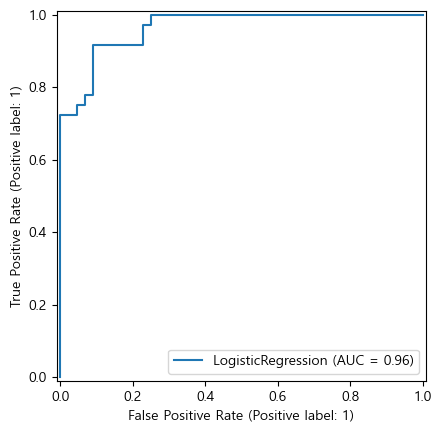

In [92]:
RocCurveDisplay.from_estimator(lr, X_test_s, y_test)

In [93]:
# 각 가중치
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef",ascending=False)
lr.coef_[0]

array([0.66240298, 0.32488882, 0.50617208, 0.62748009, 0.14616093,
       1.75286373, 0.35710735])

In [94]:
coef_df

,Features,Coef
5,CGPA,1.752864
0,GRE Score,0.662403
3,SOP,0.627480
2,University Rating,0.506172
6,Research,0.357107
1,TOEFL Score,0.324889
4,LOR,0.146161


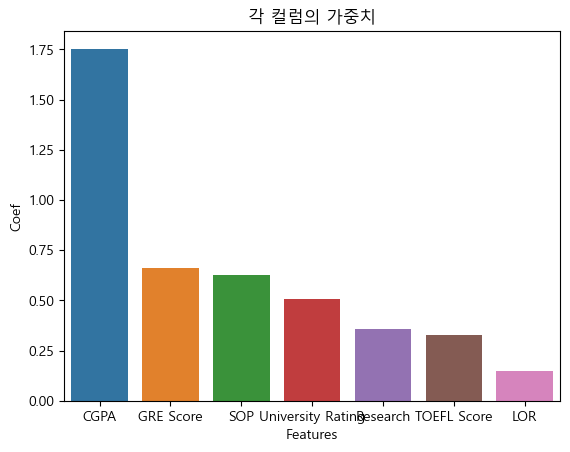

In [96]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features")
plt.title("각 컬럼의 가중치")
plt.show()

"""
"""
None

In [97]:
wrong_cases = X_test[y_test != y_pred]
wrong_cases.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
155,312,109,3,3.0,3.0,8.69,0
280,311,102,3,4.5,4.0,8.64,1
111,321,109,4,4.0,4.0,8.68,1
305,321,109,3,3.5,3.5,8.80,1
65,325,112,4,3.5,3.5,8.92,0


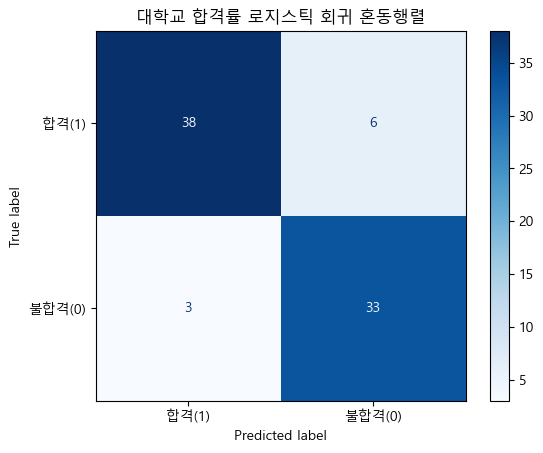

In [101]:
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_s,
    y_test,
    display_labels=["합격(1)", "불합격(0)"],
    cmap="Blues"
)

plt.title("대학교 합격률 로지스틱 회귀 혼동행렬")
plt.show()

In [102]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89        41
           1       0.92      0.85      0.88        39

    accuracy                           0.89        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.89      0.89      0.89        80

